# NIFTY Data Engine - Advanced Exploratory Data Analysis
This notebook performs a deep dive into the raw dataset to identify quirks, anomalies, and data quality issues for the Quant Singularity recruitment challenge.

In [3]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

DATA_DIR = "../Data Engine Intern Project/intern_data_db"
SPOT_DIR = os.path.join(DATA_DIR, "nifty_spot")
FUTURES_DIR = os.path.join(DATA_DIR, "nifty_futures")
OPTIONS_DIR = os.path.join(DATA_DIR, "options_chain")
AUX_DIR = os.path.join(DATA_DIR, "aux")

sns.set_theme(style="darkgrid")
print(f"Data directory set to: {DATA_DIR}")

def get_expected_timestamps(calendar_path):
    calendar = pd.read_csv(calendar_path)
    trading_days = calendar[calendar['is_trading_day'] == True]
    all_expected = []
    for _, row in trading_days.iterrows():
        expected = pd.date_range(
            start=f"{row['date']} {row['session_start']}",
            end=f"{row['date']} {row['session_end']}",
            freq='1min'
        )
        all_expected.append(pd.Series(expected))
    return pd.concat(all_expected).reset_index(drop=True)

Data directory set to: ../Data Engine Intern Project/intern_data_db


## 0. Raw Sequencing & Alignment Check (Before Sorting)
In real vendor feeds, data can arrive out of order or with duplicate timestamps. We check for these before applying any sorting.

In [4]:
print("--- [SAMPLE] NIFTY SPOT DATA ---")
print(df_spot.head())

print("\n--- [SAMPLE] NIFTY FUTURES DATA ---")
print(df_fut.head())

print("\n--- [SAMPLE] NIFTY OPTIONS DATA ---")
print(df_opt.head())


--- [SAMPLE] NIFTY SPOT DATA ---


NameError: name 'df_spot' is not defined

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell checks raw data alignment BEFORE sorting.
#   • Backward time jumps  → Error Code 1  (Bit 1):  'Backward time jump detected'
#   • Duplicate timestamps → Error Code 2  (Bit 2):  'Duplicate timestamp detected'
# =======================================================
#
#check 1

def check_raw_alignment(directory, name):
    files = sorted(glob.glob(os.path.join(directory, "*.csv")))
    for f in files:
        df = pd.read_csv(f)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
        # 1. Check Monotonicity (Applies to all)
        is_sorted = df['timestamp'].is_monotonic_increasing
        
        # 2. Check Duplicates (Skipped for OPTIONS)
        if name == "OPTIONS":
            duplicates = 0
        else:
            duplicates = df['timestamp'].duplicated().sum()
        
        # Reporting logic
        if not is_sorted or duplicates > 0:
            print(f"[ISSUE] {name} - File: {os.path.basename(f)}")
            if not is_sorted:
                jumps = df[df['timestamp'].diff() < pd.Timedelta(0)]
                print(f"  - Raw data is NOT sorted by time. Found {len(jumps)} backward time jumps.")
            if duplicates > 0:
                print(f"  - Found {duplicates} duplicate timestamps.")
        else:
            status = "well-aligned" if name != "OPTIONS" else "monotonic (duplicates expected/skipped)"
            print(f"[OK] {name} - File: {os.path.basename(f)} is {status}.")

print("--- Checking Spot Data Alignment ---")
check_raw_alignment(SPOT_DIR, "SPOT")

print("\n--- Checking Futures Data Alignment ---")
check_raw_alignment(FUTURES_DIR, "FUTURES")

print("\n--- Checking Options Data Alignment ---")
check_raw_alignment(OPTIONS_DIR, "OPTIONS")


--- Checking Spot Data Alignment ---
[OK] SPOT - File: 2025-08-22.csv is well-aligned.
[OK] SPOT - File: 2025-08-25.csv is well-aligned.
[OK] SPOT - File: 2025-08-26.csv is well-aligned.
[OK] SPOT - File: 2025-08-27.csv is well-aligned.
[OK] SPOT - File: 2025-08-28.csv is well-aligned.
[OK] SPOT - File: 2025-09-01.csv is well-aligned.
[OK] SPOT - File: 2025-09-02.csv is well-aligned.

--- Checking Futures Data Alignment ---
[OK] FUTURES - File: 2025-08-22.csv is well-aligned.
[OK] FUTURES - File: 2025-08-25.csv is well-aligned.
[OK] FUTURES - File: 2025-08-26.csv is well-aligned.
[OK] FUTURES - File: 2025-08-27.csv is well-aligned.
[OK] FUTURES - File: 2025-08-28.csv is well-aligned.
[OK] FUTURES - File: 2025-09-01.csv is well-aligned.
[OK] FUTURES - File: 2025-09-02.csv is well-aligned.

--- Checking Options Data Alignment ---
[OK] OPTIONS - File: 2025-08-22_2025-08-28.csv is monotonic (duplicates expected/skipped).
[OK] OPTIONS - File: 2025-08-22_2025-09-25.csv is monotonic (duplicat

## 1. NIFTY Spot EDA
### 1.1 Missing Candles & Abnormal Prices

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell checks Spot data quality.
#   • Missing candles (gap detection)  → Error Code 4  (Bit 4):  'Missing expected 1-minute candle'
#   • OHLC violations (Low > High etc) → Error Code 8  (Bit 8):  'OHLC integrity violation'
#   • Price spikes > 1% per minute     → Error Code 16 (Bit 16): 'Price spike > 1% in a single candle'
# =======================================================
#
#check 2

spot_files = sorted(glob.glob(os.path.join(SPOT_DIR, "*.csv")))
df_spot = pd.concat([pd.read_csv(f) for f in spot_files])
df_spot['timestamp'] = pd.to_datetime(df_spot['timestamp'])
df_spot = df_spot.sort_values('timestamp').reset_index(drop=True)

expected_ts = get_expected_timestamps(os.path.join(AUX_DIR, "nse_calendar.csv"))
missing_spot = expected_ts[~expected_ts.isin(df_spot['timestamp'])]

print(f"Total Spot Records: {len(df_spot)}")
print(f"True Missing Candles (within trading hours): {len(missing_spot)}")

# Price Abnormalities
bad_prices = df_spot[
    (df_spot['low'] <= 0) | 
    (df_spot['high'] < df_spot['low']) | 
    (df_spot['high'] < df_spot['open']) | 
    (df_spot['high'] < df_spot['close']) | 
    (df_spot['low'] > df_spot['open']) | 
    (df_spot['low'] > df_spot['close'])
]
print(f"OHLC Violations: {len(bad_prices)}")

# Sudden Spikes (> 1% in 1 minute)
df_spot['returns'] = df_spot['close'].pct_change().abs()
spikes = df_spot[df_spot['returns'] > 0.01]
print(f"Price Spikes (>1% per min): {len(spikes)}")

Total Spot Records: 2625
True Missing Candles (within trading hours): 7
OHLC Violations: 0
Price Spikes (>1% per min): 1


In [ ]:
df_spot

,timestamp,open,high,low,close,volume,returns
0,2025-08-22 09:15:00,24200.00,24208.65,24198.25,24207.14,88560,NaN
1,2025-08-22 09:16:00,24205.65,24206.11,24204.48,24205.05,307665,0.000086
2,2025-08-22 09:17:00,24206.74,24215.94,24206.39,24214.39,269462,0.000386
3,2025-08-22 09:18:00,24214.74,24239.64,24212.28,24236.46,200441,0.000911
4,2025-08-22 09:19:00,24240.71,24241.93,24232.90,24232.97,198564,0.000144
...,...,...,...,...,...,...,...
2620,2025-09-02 15:25:00,23934.07,23948.99,23931.89,23948.80,185595,0.000689
2621,2025-09-02 15:26:00,23949.57,23950.54,23924.03,23926.69,93255,0.000923
2622,2025-09-02 15:27:00,23925.13,23925.19,23921.48,23921.99,355648,0.000196
2623,2025-09-02 15:28:00,23919.76,23943.26,23919.48,23941.79,354823,0.000828


In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell builds a multi-lookback return matrix for spike analysis.
#   • Identifies candles with abnormal returns across lookback windows.
#   • Related to → Error Code 16 (Bit 16): 'Price spike > 1% in a single candle'
# =======================================================
#
#check 3

import pandas as pd

# 1. Define the lookback periods
lookbacks = [1,2,3, 5]

def create_return_matrix(df, lookbacks):
    # Ensure data is sorted by time
    df = df.sort_values('timestamp').copy()
    
    # Start the matrix with the original close price 
    # This prevents 'close not found' errors in future validation steps
    matrix_cols = {'close': df['close']}
    
    for n in lookbacks:
        col_name = f'ret_{n}b'
        # Removed .abs() so you can see direction (positive vs negative moves)
        matrix_cols[col_name] = df['close'].pct_change(periods=n).abs()
        
    # Combine into a single DataFrame
    return_matrix = pd.DataFrame(matrix_cols, index=df.index)
    
    # Add the timestamp back for context
    return_matrix.insert(0, 'timestamp', df['timestamp'])
    
    return return_matrix

# Example usage:
# Now df_features will have ['timestamp', 'close', 'ret_1b', 'ret_5b', ...]
df_features = create_return_matrix(df_spot, lookbacks)
print(df_features.tail(20))


               timestamp     close    ret_1b    ret_2b    ret_3b    ret_5b
2605 2025-09-02 15:10:00  23893.55  0.000202  0.000177  0.000644  0.000754
2606 2025-09-02 15:11:00  23898.41  0.000203  0.000002  0.000381  0.001055
2607 2025-09-02 15:12:00  23905.56  0.000299  0.000503  0.000301  0.001147
2608 2025-09-02 15:13:00  23890.77  0.000619  0.000320  0.000116  0.000061
2609 2025-09-02 15:14:00  23893.33  0.000107  0.000512  0.000213  0.000211
2610 2025-09-02 15:15:00  23861.54  0.001330  0.001223  0.001841  0.001340
2611 2025-09-02 15:16:00  23868.72  0.000301  0.001030  0.000923  0.001242
2612 2025-09-02 15:17:00  23878.53  0.000411  0.000712  0.000619  0.001131
2613 2025-09-02 15:18:00  23889.62  0.000464  0.000876  0.001177  0.000048
2614 2025-09-02 15:19:00  23883.87  0.000241  0.000224  0.000635  0.000396
2615 2025-09-02 15:20:00  23888.50  0.000194  0.000047  0.000418  0.001130
2616 2025-09-02 15:21:00  23909.58  0.000882  0.001076  0.000836  0.001712
2617 2025-09-02 15:22:00 

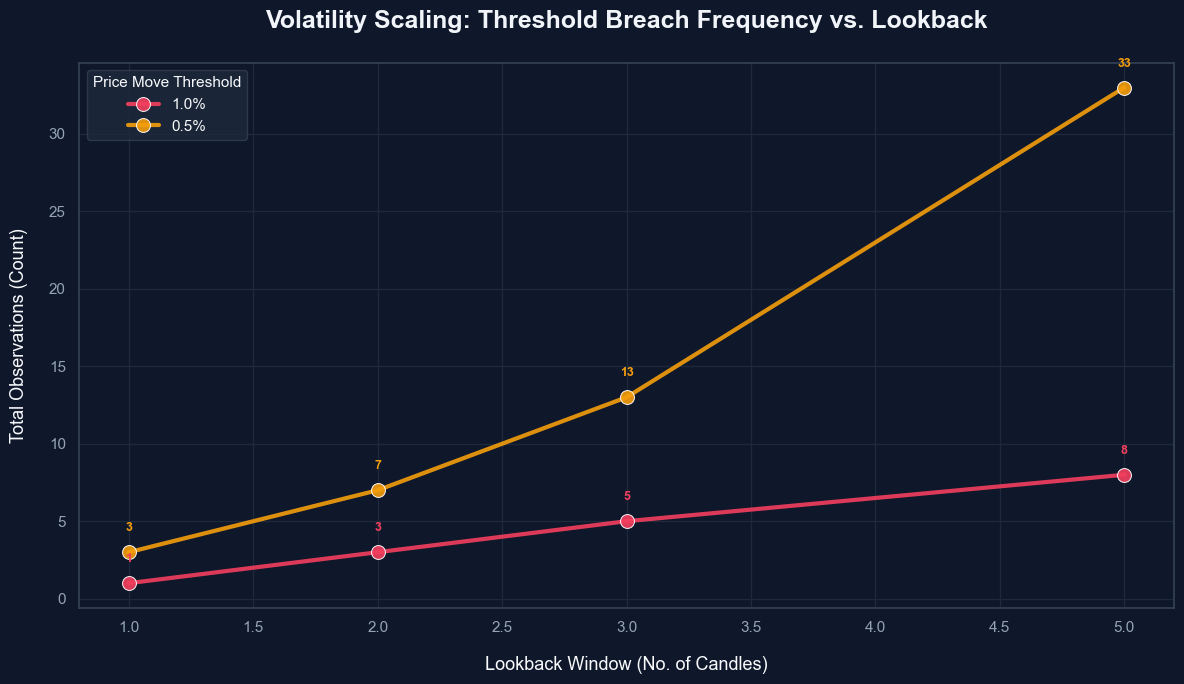

In [ ]:



import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define thresholds and professional color palette
thresholds = [0.01, 0.005, 0.0025]
threshold_labels = ['1.0%', '0.5%']
colors = ["#F43F5E", "#F59E0B", "#10B981"] # Rose, Amber, Emerald

# 2. Set dark-themed aesthetics for a premium "Quant" look
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#0f172a",  # Deep Navy background
    "axes.facecolor": "#0f172a",
    "axes.edgecolor": "#334155",
    "axes.labelcolor": "#f8fafc",
    "xtick.color": "#94a3b8",
    "ytick.color": "#94a3b8",
    "grid.color": "#1e293b",
    "text.color": "#f8fafc"
})

# 3. Prepare the data for plotting
plot_data = []
for n in lookbacks:
    col = f'ret_{n}b'
    if col in df_features.columns:
        for t, label in zip(thresholds, threshold_labels):
            # Calculate total count of candles exceeding threshold
            count = (df_features[col] >= t).sum()
            plot_data.append({
                'Lookback (Candles)': n,
                'Threshold': label,
                'Hit Count': count
            })

df_plot = pd.DataFrame(plot_data)

# 4. Create the Visualization
plt.figure(figsize=(12, 7))

# Create line plot with markers
sns.lineplot(
    data=df_plot, 
    x='Lookback (Candles)', 
    y='Hit Count', 
    hue='Threshold', 
    palette=dict(zip(threshold_labels, colors)),
    marker='o',
    markersize=10,
    linewidth=3,
    alpha=0.9
)

# 5. Styling & Annotations
plt.title('Volatility Scaling: Threshold Breach Frequency vs. Lookback', 
          fontsize=18, fontweight='bold', pad=25, color='#f1f5f9')
plt.xlabel('Lookback Window (No. of Candles)', fontsize=13, labelpad=15)
plt.ylabel('Total Observations (Count)', fontsize=13, labelpad=15)

# Add value labels for precision
for i, row in df_plot.iterrows():
    plt.annotate(f"{int(row['Hit Count'])}", 
                 (row['Lookback (Candles)'], row['Hit Count']),
                 textcoords="offset points", 
                 xytext=(0, 15), 
                 ha='center', 
                 fontsize=9, 
                 fontweight='bold',
                 color=dict(zip(threshold_labels, colors))[row['Threshold']])

# Customize Legend
legend = plt.legend(title='Price Move Threshold', title_fontsize='11', 
                    loc='upper left', frameon=True, shadow=False)
legend.get_frame().set_facecolor('#1e293b')
legend.get_frame().set_edgecolor('#334155')

plt.tight_layout()
plt.show()


In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell filters 1-minute absolute return spikes above a threshold.
#   • Related to → Error Code 16 (Bit 16): 'Price spike > 1% in a single candle'
#   (Here threshold is 0.5%, but validation.py uses 1%.)
# =======================================================
#
# check 3
n=0.005
spikes_1min = df_features[df_features['ret_1b'] > n]

print(f"Number of 1-minute abs spikes (>{n*100}%): {len(spikes_1min)}")
print(spikes_1min)

Number of 1-minute abs spikes (>0.5%): 3
               timestamp     close    ret_1b    ret_2b    ret_3b    ret_5b
839  2025-08-26 10:44:00  23660.24  0.015876  0.015525  0.015647  0.013407
1499 2025-08-27 15:29:00  23817.14  0.008834  0.010953  0.010598  0.010682
2249 2025-09-01 15:29:00  23860.91  0.005341  0.004618  0.005131  0.005038


In [ ]:
import glob
import os
import pandas as pd

def analyze_nifty_5min_spikes_batched(directory):
    # 1. Identify all daily CSV files in the spot directory
    files = sorted(glob.glob(os.path.join(directory, "*.csv")))
    
    print(f"Starting batch analysis for {len(files)} days...\n")

    for file_path in files:
        # Get date for labeling
        day_label = os.path.basename(file_path).split('.')[0]
        
        # 2. Load the daily batch
        df_1m = pd.read_csv(file_path)
        df_1m['timestamp'] = pd.to_datetime(df_1m['timestamp'])
        df_1m = df_1m.sort_values('timestamp').set_index('timestamp')
        
        # 3. Resample 1-minute to 5-minute candles
        # Aggregating correctly: Open is first, High is max, Low is min, Close is last
        df_5m = df_1m.resample('5min', label='right', closed='right').agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last'
        }).dropna()
        
        # 4. Calculate signed and absolute percentage change
        # This calculates the return between consecutive 5-minute bars
        df_5m['pct_change'] = df_5m['close'].pct_change()
        df_5m['abs_pct_change'] = df_5m['pct_change'].abs()
        
        # 5. Sort by the highest absolute percentage change
        df_sorted = df_5m.dropna().sort_values(by='abs_pct_change', ascending=False)
        
        # 6. Output the top impact bars for this day
        print(f"--- Day: {day_label} | Top 5 Most Volatile 5-Min Bars ---")
        # Formatting percentage for readability
        display_df = df_sorted[['open', 'high', 'low', 'close', 'pct_change']].head(5).copy()
        display_df['pct_change'] = display_df['pct_change'].apply(lambda x: f"{x:+.4%}")
        print(display_df)
        print("-" * 65)

# Execute using your SPOT_DIR variable
analyze_nifty_5min_spikes_batched(SPOT_DIR)


Starting batch analysis for 7 days...

--- Day: 2025-08-22 | Top 5 Most Volatile 5-Min Bars ---
                         open      high       low     close pct_change
timestamp                                                             
2025-08-22 12:45:00  24076.73  24162.64  24075.19  24162.11   +0.3573%
2025-08-22 13:40:00  24191.21  24196.50  24107.75  24109.52   -0.3509%
2025-08-22 12:15:00  24071.51  24136.90  24067.99  24136.77   +0.2718%
2025-08-22 09:30:00  24257.86  24269.91  24192.05  24192.80   -0.2670%
2025-08-22 14:30:00  24165.08  24226.70  24164.47  24222.35   +0.2427%
-----------------------------------------------------------------
--- Day: 2025-08-25 | Top 5 Most Volatile 5-Min Bars ---
                         open      high       low     close pct_change
timestamp                                                             
2025-08-25 15:30:00  24346.45  24350.72  24209.90  24226.66   -0.4791%
2025-08-25 09:55:00  24227.91  24229.58  24137.97  24144.16   -0.3446%


In [ ]:
# todo take all spikes of 1min, 5min,15 min verify price movement from options data, vix ,futures data

## 2. NIFTY Futures EDA
### 2.1 Missing Candles & Stale Prices

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell checks Futures data quality.
#   • Missing candles (gap detection)         → Error Code 4  (Bit 4):   'Missing expected 1-minute candle'
#   • Abnormal spread > 5% (near vs mid)      → Error Code 32 (Bit 32):  'Abnormal futures spread (>5%)'
#   • Stale prices (no change 5+ mins, vol>0) → Error Code 64 (Bit 64):  'Stale price (No price change for 5+ mins with volume > 0)'
# =======================================================
#
# futures check 1

# 1. Load and prepare Futures data
fut_files = sorted(glob.glob(os.path.join(FUTURES_DIR, "*.csv")))
df_fut = pd.concat([pd.read_csv(f) for f in fut_files])
df_fut['timestamp'] = pd.to_datetime(df_fut['timestamp'])
df_fut = df_fut.sort_values('timestamp').reset_index(drop=True)

# 2. Filter Expected Timestamps to exclude 15:30 (Market Close)
# This ensures we only expect candles from 09:15:00 to 15:29:00
valid_expected_ts = expected_ts[expected_ts.dt.time < pd.to_datetime("15:30:00").time()]

missing_fut = valid_expected_ts[~valid_expected_ts.isin(df_fut['timestamp'])]
print(f"Futures Missing Candles (09:15-15:29): {len(missing_fut)}")

# 3. Spread Anomaly
df_fut['spread'] = (df_fut['near_month_close'] - df_fut['mid_month_close']).abs()
df_fut['spread_pct'] = df_fut['spread'] / df_fut['near_month_close']
abnormal_spreads = df_fut[df_fut['spread_pct'] > 0.05] # Spread > 5%
print(f"Abnormal Spreads (>5%): {len(abnormal_spreads)}")

# 4. Stale Prices (No change in 5 mins while volume > 0)
# We use groupby('date') to ensure diff() doesn't compare the close of one day to the open of next
df_fut['date'] = df_fut['timestamp'].dt.date
df_fut['price_change'] = df_fut.groupby('date')['near_month_close'].diff()
df_fut['is_stale'] = (df_fut['price_change'] == 0) & (df_fut['near_month_volume'] > 0)

# Check for consecutive stale candles
stale_runs = df_fut.groupby('date')['is_stale'].rolling(window=5).sum().reset_index(0, drop=True)
print(f"Potential Stale Price Windows (5+ mins): {len(df_fut[stale_runs >= 5])}")


Futures Missing Candles (09:15-15:29): 0
Abnormal Spreads (>5%): 0
Potential Stale Price Windows (5+ mins): 0


In [ ]:
missing_fut

Series([], dtype: datetime64[ns])

## 3. Options Chain EDA
### 3.1 Snapshots & Chain Integrity

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell checks Options chain data quality.
#   • Snapshot alignment (5-min boundary)     → General data quality (no direct bitmask code)
#   • Incomplete CE/PE pairs                  → Error Code 128 (Bit 128): 'Invalid Option Strike or Side'
#   • Zero / extreme IV records               → General data quality (no direct bitmask code)
#   • OHLC integrity on options               → Error Code 8   (Bit 8):   'OHLC integrity violation'
# =======================================================
#
# options check 1

opt_files = sorted(glob.glob(os.path.join(OPTIONS_DIR, "*.csv")))
sample_opt = pd.read_csv(opt_files[0])
sample_opt['timestamp'] = pd.to_datetime(sample_opt['timestamp'])

# Snapshot Alignment Check
minutes = sample_opt['timestamp'].dt.minute % 5
non_5min_snapshots = sample_opt[minutes != 0]
print(f"Snapshots not on 5-min boundary: {len(non_5min_snapshots)}")

# Chain Completeness (Every strike should have CE and PE)
chain_counts = sample_opt.groupby(['timestamp', 'strike']).size()
incomplete_chains = chain_counts[chain_counts != 2]
print(f"Incomplete CE/PE pairs: {len(incomplete_chains)}")

# IV Analysis
zero_iv = sample_opt[sample_opt['iv'] == 0]
high_iv = sample_opt[sample_opt['iv'] > 1.0]
print(f"Zero IV Records: {len(zero_iv)}")
print(f"High IV Records (>100%): {len(high_iv)}")

Snapshots not on 5-min boundary: 0
Incomplete CE/PE pairs: 0
Zero IV Records: 0
High IV Records (>100%): 0


In [ ]:
#

## 4. Cross-Data Consistency
### 4.1 Timestamp Alignment

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell loads ALL Spot, Futures, and Options data.
#   • Data loading step — no direct error code.
#   • Prepares data for cross-market consistency checks below.
# =======================================================
#
# overall check

import glob
import os
import pandas as pd

# 1. Load ALL Spot Files
spot_files = sorted(glob.glob(os.path.join(SPOT_DIR, "*.csv")))
df_spot = pd.concat([pd.read_csv(f) for f in spot_files])
df_spot['timestamp'] = pd.to_datetime(df_spot['timestamp'])
df_spot = df_spot.sort_values('timestamp').reset_index(drop=True)

# 2. Load ALL Futures Files
fut_files = sorted(glob.glob(os.path.join(FUTURES_DIR, "*.csv")))
df_fut = pd.concat([pd.read_csv(f) for f in fut_files])
df_fut['timestamp'] = pd.to_datetime(df_fut['timestamp'])
df_fut = df_fut.sort_values('timestamp').reset_index(drop=True)

# 3. Load ALL Options Files (Note: This may take a moment)
opt_files = sorted(glob.glob(os.path.join(OPTIONS_DIR, "*.csv")))
df_opt = pd.concat([pd.read_csv(f) for f in opt_files])
df_opt['timestamp'] = pd.to_datetime(df_opt['timestamp'])
df_opt = df_opt.sort_values(['timestamp', 'strike']).reset_index(drop=True)

print(f"Data Loaded for all days.")
print(f"Spot: {df_spot['timestamp'].dt.date.nunique()} days")
print(f"Futures: {df_fut['timestamp'].dt.date.nunique()} days")
print(f"Options: {df_opt['timestamp'].dt.date.nunique()} days")


Data Loaded for all days.
Spot: 7 days
Futures: 7 days
Options: 7 days


In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell runs 5 cross-data consistency checks:
#   VALIDATION 1 – Timestamp Synchronization
#     • Related to → Error Code 2  (Bit 2):  'Duplicate timestamp detected'
#   VALIDATION 2 – Basis Stability (Spot vs Futures)
#     • Related to → Error Code 32 (Bit 32): 'Abnormal futures spread (>5%)'
#   VALIDATION 3 – Options Arbitrage Violations (Intrinsic Value)
#     • Related to → Error Code 8  (Bit 8):  'OHLC integrity violation'
#   VALIDATION 4 – Frozen Data (O=H=L=C bars)
#     • Related to → Error Code 64 (Bit 64): 'Stale price (No price change for 5+ mins)'
#   VALIDATION 5 – IV Sanity (zero or extreme IV)
#     • General data quality (no direct bitmask code)
# =======================================================
#
# check 

print("--- [VALIDATION 1] Timestamp Synchronization ---")
ts_spot = set(df_spot['timestamp'])
ts_fut = set(df_fut['timestamp'])
common = ts_spot.intersection(ts_fut)
print(f"Common timestamps (Spot vs Fut): {len(common)} / {len(ts_spot)}")
if len(ts_spot) != len(ts_fut):
    print(f"MISMATCH: {abs(len(ts_spot)-len(ts_fut))} missing bars between Spot and Futures.")

print("\n--- [VALIDATION 2] Basis Stability (Spot vs Futures) ---")
# Check if Futures price stays logically aligned with Spot
# Fixed: Using 'near_month_close' for Futures
merged_basis = pd.merge(df_spot[['timestamp', 'close']], df_fut[['timestamp', 'near_month_close']], 
                        on='timestamp')
merged_basis['basis'] = merged_basis['near_month_close'] - merged_basis['close']
basis_std = merged_basis['basis'].std()
basis_anomalies = merged_basis[merged_basis['basis'].abs() > (merged_basis['basis'].mean() + 3*basis_std)]
print(f"Basis Anomalies (>3 StdDev): {len(basis_anomalies)}")

print("\n--- [VALIDATION 3] Options Arbitrage Violations ---")
# Check if any Option is priced below its Intrinsic Value (Spot - Strike)
df_opt_val = pd.merge(df_opt, df_spot[['timestamp', 'close']], on='timestamp')
df_opt_val['intrinsic'] = np.where(df_opt_val['side'] == 'CE', 
                                 (df_opt_val['close_y'] - df_opt_val['strike']).clip(lower=0),
                                 (df_opt_val['strike'] - df_opt_val['close_y']).clip(lower=0))

violations = df_opt_val[df_opt_val['close_x'] < df_opt_val['intrinsic'] * 0.98] # 2% slippage buffer
print(f"Intrinsic Value Violations: {len(violations)}")

print("\n--- [VALIDATION 4] Frozen Data Check ---")
# Fixed: Handled Spot and Futures column names separately
frozen_spot = df_spot[(df_spot['open'] == df_spot['high']) & (df_spot['low'] == df_spot['close'])].shape[0]
print(f"Spot Frozen Bars (O=H=L=C): {frozen_spot} ({frozen_spot/len(df_spot):.2%})")

frozen_fut = df_fut[(df_fut['near_month_open'] == df_fut['near_month_high']) & (df_fut['near_month_low'] == df_fut['near_month_close'])].shape[0]
print(f"Fut Frozen Bars (O=H=L=C): {frozen_fut} ({frozen_fut/len(df_fut):.2%})")

print("\n--- [VALIDATION 5] IV Sanity ---")
bad_iv = df_opt[(df_opt['iv'] <= 0) | (df_opt['iv'] > 1.5)].shape[0] # IV > 150% is extreme for Nifty
print(f"Extreme/Zero IV records: {bad_iv}")


--- [VALIDATION 1] Timestamp Synchronization ---
Common timestamps (Spot vs Fut): 2625 / 2625

--- [VALIDATION 2] Basis Stability (Spot vs Futures) ---
Basis Anomalies (>3 StdDev): 6

--- [VALIDATION 3] Options Arbitrage Violations ---
Intrinsic Value Violations: 0

--- [VALIDATION 4] Frozen Data Check ---
Spot Frozen Bars (O=H=L=C): 0 (0.00%)
Fut Frozen Bars (O=H=L=C): 0 (0.00%)

--- [VALIDATION 5] IV Sanity ---
Extreme/Zero IV records: 0



Quantitative models to validate prices

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell performs DELTA-BASED TRIANGULATION to classify spot spikes.
#   • REAL MARKET SPIKE   — All 3 markets agree: no error flagged.
#   • BAD DATA (SPOT)     → Error Code 256  (Bit 256):  'Triangulation: Isolated Spot Anomaly'
#   • BAD DATA (FUTURES)  → Error Code 512  (Bit 512):  'Triangulation: Isolated Futures Anomaly'
#   • UNCERTAIN / MIXED   — Inconclusive; may warrant manual review.
#   (Options anomaly)     → Error Code 1024 (Bit 1024): 'Triangulation: Isolated Options Anomaly'
# =======================================================
#
#check

import pandas as pd
import numpy as np

print("="*60)
print(" DELTA-BASED TRIANGULATION (SPIKE VALIDATION)")
print("="*60)

# 1. Calculate Spot Changes (Delta S)
df_spot_diff = df_spot[['timestamp', 'close']].copy().sort_values('timestamp')
df_spot_diff['delta_S'] = df_spot_diff['close'].diff()

# 2. Calculate Futures Changes (Delta F)
df_fut_diff = df_fut[['timestamp', 'near_month_close']].copy().sort_values('timestamp')
df_fut_diff['delta_F'] = df_fut_diff['near_month_close'].diff()

# 3. Calculate Options Changes (Delta O)
# Get Calls and Puts
df_ce = df_opt[df_opt['side'] == 'CE'][['timestamp', 'strike', 'close']]
df_pe = df_opt[df_opt['side'] == 'PE'][['timestamp', 'strike', 'close']]
df_opt_pairs = pd.merge(df_ce, df_pe, on=['timestamp', 'strike'], suffixes=('_ce', '_pe'))

# Calculate Synthetic Future (C - P)
df_opt_pairs['syn_fut'] = df_opt_pairs['close_ce'] - df_opt_pairs['close_pe']

# Calculate minute-to-minute change for EACH strike
df_opt_pairs = df_opt_pairs.sort_values(['strike', 'timestamp'])
df_opt_pairs['delta_O_strike'] = df_opt_pairs.groupby('strike')['syn_fut'].diff()

# Use the median change across all strikes to filter out illiquid options
df_opt_diff = df_opt_pairs.groupby('timestamp')['delta_O_strike'].median().reset_index()
df_opt_diff.rename(columns={'delta_O_strike': 'delta_O'}, inplace=True)

# 4. Merge all Deltas together
df_tri = pd.merge(df_spot_diff, df_fut_diff, on='timestamp')
df_tri = pd.merge(df_tri, df_opt_diff, on='timestamp')

# 5. Define SPIKE and Triangulation Logic
SPIKE_THRESHOLD = 50 # A move of >30 points in 1 minute is considered a spike
TOLERANCE = 15       # Instruments can naturally deviate by up to 15 points during high volatility

# Extract only the timestamps where Spot spiked
spot_spikes = df_tri[df_tri['delta_S'].abs() > SPIKE_THRESHOLD].copy()

def validate_spike(row):
    dS = row['delta_S']
    dF = row['delta_F']
    dO = row['delta_O']
    
    # Check 1: Did Futures and Options also spike and match Spot?
    if abs(dS - dF) <= TOLERANCE and abs(dS - dO) <= TOLERANCE:
        return "✅ REAL MARKET SPIKE"
    
    # Check 2: Do Futures and Options agree with EACH OTHER, but disagree with Spot?
    if abs(dF - dO) <= TOLERANCE and abs(dS - dF) > TOLERANCE and abs(dS - dO) > TOLERANCE:
        return "❌ BAD DATA (SPOT ANOMALY)"
        
    # Check 3: If nothing aligns clearly
    return "⚠️ UNCERTAIN / MIXED"

# Apply classification
if not spot_spikes.empty:
    spot_spikes['Validation'] = spot_spikes.apply(validate_spike, axis=1)
    
    # Format output for easy reading
    output = spot_spikes[['timestamp', 'close', 'delta_S', 'delta_F', 'delta_O', 'Validation']].copy()
    output.rename(columns={'close': 'Spot_Price', 'delta_S': 'Spot_Change', 'delta_F': 'Fut_Change', 'delta_O': 'Opt_Change'}, inplace=True)
    
    print(f"Detected {len(output)} Spikes in Spot Data (> {SPIKE_THRESHOLD} pts/min).\n")
    print(output.to_string(index=False))
else:
    print(f"No Spot spikes greater than {SPIKE_THRESHOLD} points detected in this batch.")


 DELTA-BASED TRIANGULATION (SPIKE VALIDATION)
Detected 2 Spikes in Spot Data (> 50 pts/min).

          timestamp  Spot_Price  Spot_Change  Fut_Change  Opt_Change           Validation
2025-08-26 09:20:00    24145.89        51.40       56.69    -219.045 ⚠️ UNCERTAIN / MIXED
2025-08-26 10:45:00    23606.39       -53.85      -52.70     -32.490 ⚠️ UNCERTAIN / MIXED


In [ ]:
# 1. Spot vs Futures Model (`E_SF`)

E_{SF}=F-S e^{(r-q)t}

This model is based on the **Cost-of-Carry pricing model** for futures contracts. The idea is that a futures contract should not trade independently of the spot asset because an arbitrage trader can replicate futures exposure using the underlying asset plus financing. If you buy the index today in the spot market, you must finance that purchase using borrowed capital at the risk-free interest rate `r`. At the same time, if the index distributes dividends, you receive those dividends while holding the position, represented by `q` (dividend yield). Therefore, the fair futures price becomes the spot price adjusted upward by financing cost and downward by expected dividends.

Mathematically, the theoretical futures price is:

F=S e^{(r-q)t}

where:

* `S` = spot price
* `F` = futures price
* `r` = risk-free rate
* `q` = dividend yield
* `t` = time to expiry in years

The exponential term appears because financing is assumed to compound continuously. This is the standard institutional pricing framework used in index futures, commodity futures, and equity derivatives.

Your error vector `E_SF` measures how far the observed futures price deviates from its theoretical fair value. If the error is near zero, the spot and futures markets are internally consistent. If the error becomes large, one of several things may be happening:

* stale or delayed spot ticks
* futures mispricing
* incorrect timestamps
* temporary arbitrage gaps
* dividend expectation mismatch
* funding market dislocations

This model is extremely important because futures markets are often more liquid and react faster than spot markets. In high-frequency environments, futures frequently lead price discovery. Therefore, persistent positive or negative `E_SF` values can indicate synchronization issues in your spot feed. In your triangulation engine, this error vector acts as the first structural consistency check between the cash market and the derivatives market.

---

# 2. Futures vs Options Model (`E_FO`)

E_{FO}=(C-P)-(F-K)e^{-rt}

This model comes from **Put-Call Parity using Futures**. Put-call parity is one of the most fundamental no-arbitrage relationships in derivatives pricing. It states that the difference between a call option and a put option with the same strike and expiry should equal the discounted intrinsic value implied by the underlying futures contract. The relationship exists because different portfolios can synthetically replicate each other, meaning markets must price them equivalently to avoid risk-free arbitrage.

The classical futures-based parity equation is:

C-P=(F-K)e^{-rt}

where:

* `C` = call option premium
* `P` = put option premium
* `F` = futures price
* `K` = strike price
* `r` = risk-free rate
* `t` = time to expiry

The right side represents the present value of the futures intrinsic payoff. Discounting is required because the payoff occurs at expiry rather than immediately.

Your error vector `E_FO` computes the residual difference between observed option prices and the value implied by futures parity. When the residual is close to zero, the options chain and futures market are synchronized. Large deviations imply inconsistencies such as:

* incorrect option premiums
* stale options quotes
* broken bid/ask snapshots
* futures lag
* volatility spikes causing temporary dislocations
* low-liquidity strikes

This model is especially powerful because options markets encode a massive amount of information about volatility expectations and future price distributions. Since options and futures are both derivative instruments, they often remain internally consistent even when spot feeds experience delays. In your triangulation framework, if `E_FO` remains small while other errors become large, it strongly suggests that spot prices are the corrupted leg rather than derivatives data.

---

# 3. Spot vs Options Model (`E_SO`)

E_{SO}=(C-P)-\left(Se^{(r-q)t}-K\right)e^{-rt}

This model combines the **Cost-of-Carry framework** with **Put-Call Parity**, directly relating spot prices to option prices without relying on futures prices. Instead of using the traded futures contract, the model first constructs the theoretical forward value from the spot market using financing and dividend adjustments. It then checks whether option prices are consistent with that synthetic forward.

The underlying theoretical relationship is:

C-P=\left(Se^{(r-q)t}-K\right)e^{-rt}

This equation says that the call-put spread should equal the discounted difference between the theoretical forward price and the strike price. Essentially, it creates a bridge from spot → forward → options entirely through no-arbitrage principles.

Your `E_SO` vector measures how far the observed option market deviates from what the spot market implies. If this error becomes large, it may indicate:

* option pricing inconsistencies
* stale spot prices
* bad dividend assumptions
* incorrect expiry handling
* timestamp mismatch
* low-liquidity strikes
* temporary arbitrage windows

This model is especially valuable because it provides a completely independent validation path separate from the traded futures market. In your system, you now have three interconnected relationships:

* Spot ↔ Futures
* Futures ↔ Options
* Spot ↔ Options

That triangular structure is what enables fault isolation. If two relationships agree and one breaks, you can infer which market leg is likely corrupted. This is much stronger than checking any single parity equation independently because it converts pricing theory into a probabilistic anomaly localization system.



SyntaxError: invalid syntax (1892435194.py, line 3)

In [ ]:
# === VALIDATION ERROR CODE MAPPING (validation.py) ===
# This cell performs VOLATILITY-AWARE TRIANGULAR VALIDATION
# using VIX-scaled dynamic thresholds on E_SF, E_FO, E_SO error vectors.
#   • Isolated Spot anomaly    → Error Code 256  (Bit 256):  'Triangulation: Isolated Spot Anomaly'
#   • Isolated Futures anomaly → Error Code 512  (Bit 512):  'Triangulation: Isolated Futures Anomaly'
#   • Isolated Options anomaly → Error Code 1024 (Bit 1024): 'Triangulation: Isolated Options Anomaly'
# =======================================================
#
#chec

import pandas as pd
import numpy as np
import os

print("="*60)
print(" VOLATILITY-AWARE TRIANGULAR VALIDATION ")
print("="*60)
# 1. Load VIX Data (india_vix.csv has columns: timestamp, vix_close)
df_vix = pd.read_csv(os.path.join(AUX_DIR, "india_vix.csv"))
df_vix['timestamp'] = pd.to_datetime(df_vix['timestamp'])

# 2. Prepare Unison Data (Merging Spot, Fut, Opt, and VIX)
df_ce = df_opt[df_opt['side'] == 'CE'][['timestamp', 'strike', 'close']]
df_pe = df_opt[df_opt['side'] == 'PE'][['timestamp', 'strike', 'close']]
df_options_pairs = pd.merge(df_ce, df_pe, on=['timestamp', 'strike'], suffixes=('_ce', '_pe'))

df_unison = pd.merge(df_spot[['timestamp', 'close']], 
                     df_fut[['timestamp', 'near_month_expiry', 'near_month_close']], 
                     on='timestamp')
df_unison = pd.merge(df_unison, df_options_pairs, on='timestamp')
df_unison = pd.merge(df_unison, df_vix[['timestamp', 'vix_close']], on='timestamp')

# Calculate Time to expiry (t)
df_unison['expiry_dt'] = pd.to_datetime(df_unison['near_month_expiry']) + pd.Timedelta(hours=15, minutes=30)
df_unison['t'] = (df_unison['expiry_dt'] - df_unison['timestamp']).dt.total_seconds() / (365 * 24 * 3600)

# 3. Calculate Error Vectors using ORIGINAL column names
RISK_FREE_RATE, DIVIDEND_YIELD = 0.065, 0.012

# Error 1: Spot vs Futures
df_unison['E_SF'] = df_unison['near_month_close'] - df_unison['close'] * np.exp((RISK_FREE_RATE - DIVIDEND_YIELD) * df_unison['t'])

# Error 2: Futures vs Options
df_unison['E_FO'] = (df_unison['close_ce'] - df_unison['close_pe']) - (df_unison['near_month_close'] - df_unison['strike']) * np.exp(-RISK_FREE_RATE * df_unison['t'])

# Error 3: Spot vs Options
df_unison['E_SO'] = (df_unison['close_ce'] - df_unison['close_pe']) - (df_unison['close'] * np.exp((RISK_FREE_RATE - DIVIDEND_YIELD) * df_unison['t']) - df_unison['strike']) * np.exp(-RISK_FREE_RATE * df_unison['t'])

# 4. VOLATILITY-AWARE DYNAMIC THRESHOLDS
# Using 'vix_close' directly
BASE_THRESH_SF = 20
BASE_THRESH_OPT = 50
df_unison['T_SF'] = BASE_THRESH_SF * (df_unison['vix_close'] / 15.0)
df_unison['T_OPT'] = BASE_THRESH_OPT * (df_unison['vix_close'] / 15.0)

# 5. Triangulation Logic
spot_bad = (df_unison['E_FO'].abs() <= df_unison['T_OPT']) & (df_unison['E_SF'].abs() > df_unison['T_SF']) & (df_unison['E_SO'].abs() > df_unison['T_OPT'])
fut_bad = (df_unison['E_SO'].abs() <= df_unison['T_OPT']) & (df_unison['E_SF'].abs() > df_unison['T_SF']) & (df_unison['E_FO'].abs() > df_unison['T_OPT'])
opt_bad = (df_unison['E_SF'].abs() <= 0.1*df_unison['T_SF']) & (0.2*df_unison['E_SO'].abs() > df_unison['T_OPT']) & (0.14*df_unison['E_FO'].abs() > df_unison['T_OPT'])

# 6. Isolated Anomaly Filtering (Using original column names in output)
anomaly_spot = df_unison[spot_bad][['timestamp', 'close', 'near_month_close', 'vix_close', 'E_SF']].drop_duplicates(subset=['timestamp'])
anomaly_fut = df_unison[fut_bad][['timestamp', 'close', 'near_month_close', 'vix_close', 'E_SF']].drop_duplicates(subset=['timestamp'])
anomaly_opt = df_unison[opt_bad][['timestamp', 'strike', 'close_ce', 'close_pe', 'vix_close', 'E_FO']]

# 7. Storage and Reporting
output_dir = "anomaly_dfs"
os.makedirs(output_dir, exist_ok=True)

anomaly_spot.to_csv(f"{output_dir}/anomaly_spot.csv", index=False)
anomaly_fut.to_csv(f"{output_dir}/anomaly_fut.csv", index=False)
anomaly_opt.to_csv(f"{output_dir}/anomaly_opt.csv", index=False)

print(f"Isolated Spot Anomalies: {len(anomaly_spot)}")
print(f"Isolated Futures Anomalies: {len(anomaly_fut)}")
print(f"Isolated Options Anomalies: {len(anomaly_opt)}")

if len(anomaly_spot) > 0: print("\n--- SPOT ANOMALIES ---\n", anomaly_spot)
if len(anomaly_fut) > 0: print("\n--- FUTURES ANOMALIES ---\n", anomaly_fut)
if len(anomaly_opt) > 0: print("\n--- OPTIONS ANOMALIES ---\n", anomaly_opt.head())

# 7. Storage and Reporting
output_dir = "anomaly_dfs"
os.makedirs(output_dir, exist_ok=True)

anomaly_spot.to_csv(f"{output_dir}/anomaly_spot.csv", index=False)
anomaly_fut.to_csv(f"{output_dir}/anomaly_fut.csv", index=False)
anomaly_opt.to_csv(f"{output_dir}/anomaly_opt.csv", index=False)

print(f"Isolated Spot Anomalies: {len(anomaly_spot)}")
print(f"Isolated Futures Anomalies: {len(anomaly_fut)}")
print(f"Isolated Options Anomalies: {len(anomaly_opt)}")

if len(anomaly_spot) > 0: print("\n--- SPOT ANOMALIES ---\n", anomaly_spot)
if len(anomaly_fut) > 0: print("\n--- FUTURES ANOMALIES ---\n", anomaly_fut)
if len(anomaly_opt) > 0: print("\n--- OPTIONS ANOMALIES ---\n", anomaly_opt.head())


 VOLATILITY-AWARE TRIANGULAR VALIDATION (NO RENAMING)
Isolated Spot Anomalies: 19
Isolated Futures Anomalies: 44
Isolated Options Anomalies: 85

--- SPOT ANOMALIES ---
                 timestamp     close  near_month_close  vix_close       E_SF
35138 2025-08-28 09:25:00  23733.91          23775.07      15.46  40.286444
35374 2025-08-28 09:35:00  23768.93          23808.42      15.59  38.639124
36366 2025-08-28 10:20:00  23937.95          23974.32      15.74  35.621700
36622 2025-08-28 10:30:00  23964.43          23998.38      15.61  33.225038
37254 2025-08-28 11:00:00  23956.41          23987.60      15.57  30.537753
37406 2025-08-28 11:05:00  23983.83          24013.75      15.50  29.279099
38202 2025-08-28 11:40:00  23965.96          23991.45      15.22  24.934162
38394 2025-08-28 11:45:00  23983.69          24009.52      15.23  25.285843
38434 2025-08-28 11:50:00  23975.11          24000.58      15.17  24.938126
46131 2025-09-02 10:30:00  23839.41          23842.99      14.01  20.16